In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
class SignalDetection:
    def __init__(self, hits, misses, false_alarm, correct_rejections):
        self.__validate_count("hits", hits)
        self.__validate_count("misses", misses)
        self.__validate_count("false_alarm", false_alarm)
        self.__validate_count("correct_rejections", correct_rejections)
        self.__hits = int(hits)
        self.__misses = int(misses)
        self.__false_alarm = int(false_alarm)
        self.__correct_rejections = int(correct_rejections)

    def __validate_count(self, name, value):
        if isinstance(value,bool):
            raise TypeError(f"{name} must be an integer, got {value} instead")
        if not isinstance(value, int):
            raise TypeError(f"{name} must be an integer")
        if value < 0:
            raise ValueError(f"{name} must be a non-negative integer")

    def hit_rate(self):
        total = self.__hits + self.__misses
        # avoid division by zero
        if total == 0:
            return float('nan')

        return self.__hits / total

    def false_alarm_rate(self):
        total = self.__false_alarm + self.__correct_rejections
        # avoid division by zero
        if total == 0:
            return float('nan') 

        return self.__false_alarm / total

    def d_prime(self):
        hit_rate = self.hit_rate()
        fa_rate = self.false_alarm_rate()

        d_prime = norm.ppf(hit_rate) - norm.ppf(fa_rate)
        return d_prime

    def criterion(self):
        hit_rate = self.hit_rate()
        fa_rate = self.false_alarm_rate()

        return -0.5 * (norm.ppf(hit_rate) + norm.ppf(fa_rate))
    
    
    def __add__(self,other):
        if not isinstance(other, SignalDetection):
            raise TypeError(
                "Only SignalDetection instances can be added together"
                )
        
        return SignalDetection(
            self.__hits + other.__hits,
            self.__misses + other.__misses,
            self.__false_alarm + other.__false_alarm,
            self.__correct_rejections + other.__correct_rejections
        )
    
    def __sub__(self,other):
        if not isinstance(other, SignalDetection):
            raise TypeError(
                "Only SignalDetection instances can be subtracted from each other"
                )
        
        return SignalDetection(
            self.__hits - other.__hits,
            self.__misses - other.__misses,
            self.__false_alarm - other.__false_alarm,
            self.__correct_rejections - other.__correct_rejections
        )
    
    def __mul__(self,factor):
        if not isinstance(factor, (int, float)):
            raise TypeError(
                "SignalDetection instances can only be multiplied by a scalar"
                )
        if isinstance(factor, float):
            raise TypeError(
                "SignalDetection instances can only be multiplied by an integer"
                )
        
        return SignalDetection(
            self.__hits * factor,
            self.__misses * factor,
            self.__false_alarm * factor,
            self.__correct_rejections * factor
        )
    
    def plot_sdt(self):
        hit_rate = self.hit_rate()
        fa_rate = self.false_alarm_rate()

        # Create a grid of points for the normal distribution
        x = np.linspace(-4, 4, 1000)
        y_signal = norm.pdf(x, loc=self.d_prime(), scale=1)
        y_noise = norm.pdf(x, loc=0, scale=1)

        plt.figure(figsize=(10, 6))
        plt.plot(x, y_signal, label='Signal + Noise', color='blue')
        plt.plot(x, y_noise, label='Noise Only', color='orange')
        plt.fill_between(
            x, y_signal, where=(x >= norm.ppf(hit_rate)), 
            color='blue', alpha=0.5, label='Hits'
            )
        plt.fill_between(
            x, y_noise, where=(x >= norm.ppf(fa_rate)), 
            color='orange', alpha=0.5, label='False Alarms'
            )
        plt.axvline(
            x=norm.ppf(hit_rate), color='blue', 
            linestyle='--', label='Hit Rate Threshold'
            )
        plt.axvline(
            x=norm.ppf(fa_rate), color='orange', 
            linestyle='--', label='False Alarm Rate Threshold'
            )
        plt.title('Signal Detection Theory Visualization')
        plt.xlabel('Decision Variable')
        plt.ylabel('Probability Density')
        plt.legend()
        plt.grid()
        plt.show()

    def plot_roc(self):
        hit_rate = self.hit_rate()
        fa_rate = self.false_alarm_rate()

        plt.figure(figsize=(6, 6))
        plt.plot(fa_rate, hit_rate, marker='o', label='ROC Point')
        plt.plot(
            [0, 1], [0, 1], 
            linestyle='--', color='gray', 
            label='Chance Level'
            )
        plt.title('ROC Curve')
        plt.xlabel('False Alarm Rate')
        plt.ylabel('Hit Rate')
        plt.xlim(0, 1)
        plt.ylim(0, 1)
        plt.legend()
        plt.grid()
        plt.show()

In [42]:
for args in [
    (-1, 20, 20, 80),          # negative
    (80, 20, 20, "eighty"),    # string
    (80, 20, 20, True),        # bool
    (80, 20, 20, 3.7),         # non-whole float
    (80, 20, 20, float("nan")),# nan
    (80, 20, 20, float("inf")),# inf
    (80, 20, 20, None),        # None
]:
    try:
        SignalDetection(*args)
        print(f"FAILED TO REJECT: {args}")
    except (TypeError, ValueError) as e:
        print(f"correctly rejected {args}: {e}")

correctly rejected (-1, 20, 20, 80): hits must be a non-negative integer
correctly rejected (80, 20, 20, 'eighty'): correct_rejections must be an integer
correctly rejected (80, 20, 20, True): correct_rejections must be an integer, got True instead
correctly rejected (80, 20, 20, 3.7): correct_rejections must be an integer
correctly rejected (80, 20, 20, nan): correct_rejections must be an integer
correctly rejected (80, 20, 20, inf): correct_rejections must be an integer
correctly rejected (80, 20, 20, None): correct_rejections must be an integer


In [43]:
sd = SignalDetection(80, 20, 20, 80)
print(sd.hit_rate())          # 0.8
print(sd.false_alarm_rate())  # 0.2
print(sd.d_prime())           # ~1.683
print(sd.criterion())         # ~0.0

0.8
0.2
1.6832424671458286
-5.551115123125783e-17


In [44]:
a = SignalDetection(50, 10, 10, 50)
b = SignalDetection(30, 10, 5, 40)

c = a + b
print(f"a + b: hits={c.hit_rate()}")  # (50+30)/(50+10+30+10) = 0.8

d = a - b
print(f"a - b: works")  # should succeed since a >= b componentwise

e = a * 2
print(f"a * 2: works")

# Should all fail
for label, op in [
    ("a + 5",     lambda: a + 5),
    ("a - 'x'",   lambda: a - "x"),
    ("a * 'x'",   lambda: a * "x"),
    ("a * True",  lambda: a * True),
    ("b - a",     lambda: b - a),      # would produce negatives
    ("a * -1",    lambda: a * -1),     # would produce negatives
    ("a * 2.5",   lambda: a * 2.5),    # would produce non-integers
]:
    try:
        op()
        print(f"FAILED TO REJECT: {label}")
    except (TypeError, ValueError) as e:
        print(f"correctly rejected {label}: {e}")

a + b: hits=0.8
a - b: works
a * 2: works
correctly rejected a + 5: Only SignalDetection instances can be added together
correctly rejected a - 'x': Only SignalDetection instances can be subtracted from each other
correctly rejected a * 'x': SignalDetection instances can only be multiplied by a scalar
FAILED TO REJECT: a * True
correctly rejected b - a: hits must be a non-negative integer
correctly rejected a * -1: Scalor must be a non-negative number
FAILED TO REJECT: a * 2.5


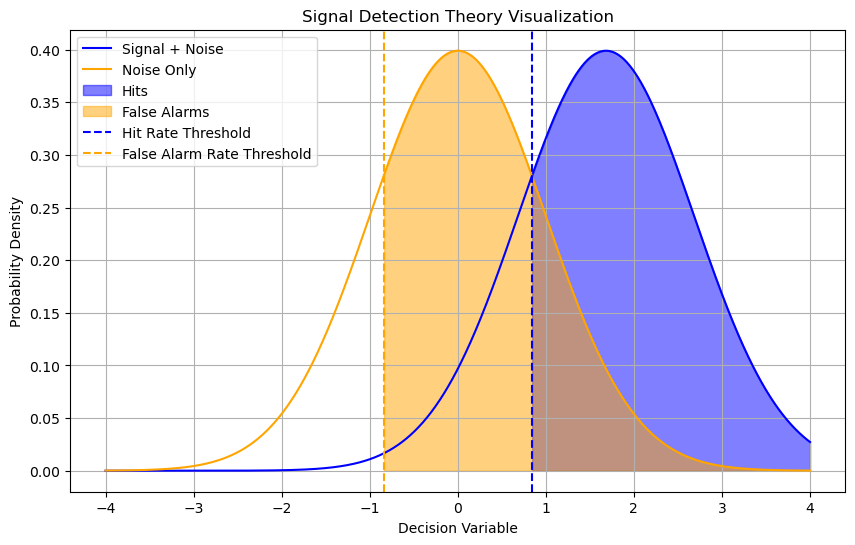

In [47]:
sd = SignalDetection(80, 20, 20, 80)
sd.plot_sdt()